# AI Math

## 사전 준비

### 패키지 설치

In [1]:
!pip install pandas seaborn numpy matplotlib tqdm

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\SSAFY\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm

### 데이터셋 가져오기

In [5]:
df = sns.load_dataset('diamonds')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [6]:
categorical_cols = df.select_dtypes(include=['category']).columns.tolist()
categorical_cols

['cut', 'color', 'clarity']

In [7]:
continuous_cols = df.select_dtypes(include=['number']).columns.tolist()
continuous_cols

['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

In [8]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [9]:
### 데이터셋 표준화

In [10]:
xmat_raw = df[continuous_cols].values

# 평균 계산
mu = xmat_raw.mean(axis=0)
# 표준편차 계산
std = xmat_raw.std(axis=0)

# 표준편차가 0인 데이터의 표준편차를 작은 값(epsillon)으로 교체
epsillon = 1e-8
import numpy as np
std = np.where(std == 0, epsillon, std)

# 표준화
xmat_norm = (xmat_raw - mu) / std
xmat_norm

array([[-1.19816781, -0.17409151, -1.09967199, ..., -1.58783745,
        -1.53619556, -1.57112919],
       [-1.24036129, -1.36073849,  1.58552871, ..., -1.64132529,
        -1.65877419, -1.74117497],
       [-1.19816781, -3.38501862,  3.37566251, ..., -1.49869105,
        -1.45739502, -1.74117497],
       ...,
       [-0.20662095,  0.73334442,  1.13799526, ..., -0.06343409,
        -0.04774083,  0.03013526],
       [ 0.13092691, -0.52310533,  0.24292836, ...,  0.37338325,
         0.33750627,  0.28520393],
       [-0.10113725,  0.31452784, -1.09967199, ...,  0.08811478,
         0.11861587,  0.14349912]], shape=(53940, 7))

## 수학으로 정답 구하기

### 비용함수

결정한 파라미터($\theta$)를 바탕으로 실제 데이터($X$)를 가지고 추측한 결과($y$)와 실제 답($\hat{y}$)을 바탕으로
파라미터가 얼마나 잘 만들어졌는지 판단하는 기준

### 평균 제곱 오차 (Mean Square Error)

추측한 결과와 실제 답의 오차의 제곱의 평균을 비용함수로 사용하는 방법

$J(\theta) = \frac{1}{n}\sum_{i=1}^{n}(\hat{y_i} - \theta x)^2$

### 정규방정식을 이용한 풀이

비용함수 MSE는 최종적으로 $\theta$에 대한 2차 방정식으로 미분과 선형대수학으로 
비용함수가 최소가 되는 $\theta$를 구할 수 있다.

$\mathbf{\theta} = (\mathbf{X}^\mathsf{T}\mathbf{X})^{-1}\mathbf{X}^\mathsf{T}\mathbf{y}$

In [11]:
import pandas as pd
xmat_df = pd.DataFrame(xmat_norm, columns=continuous_cols)
# 가격을 예측하는게 목적임으로 가격은 분리
xmat = xmat_df.drop(labels='price', axis=1).values
y = xmat_df['price'].values

# 절편항 추가 (Feature가 없을 때 추측값)
m, _ = xmat_norm.shape
xmat_wbeta = np.c_[np.ones((m, 1)), xmat_norm]

# 정규방정식으로 theta 구하기
xmat_trans = xmat_wbeta.T
theta = np.linalg.inv(xmat_trans @ xmat_wbeta) @ xmat_trans @ y
theta

array([ 2.37657116e-16,  1.31786942e-14, -1.05774764e-15, -4.78892100e-16,
        1.00000000e+00, -1.72709069e-14,  5.66712476e-16,  7.63180751e-15])

In [12]:
# 구한 theta의 평균제곱오차
y_result = xmat_wbeta @ theta
mse = np.mean((y_result - y) ** 2)
print(f'mse for normal equation: {mse}')

mse for normal equation: 1.120028647155832e-29


In [13]:
# 시각화 함수
def plot_prediction(y_true, y_pred):
    import matplotlib.pyplot as plt
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    assert y_true.shape == y_pred.shape, f"Size mismatch between y_true and y_pred"

    fig, ax = plt.subplots(figsize=(6, 4))

    # 회귀선
    sns.scatterplot(x=y_true, y=y_pred,
                    alpha=0.5, label="Model Prediction", ax=ax)

    # 이상적인 예측선
    sns.lineplot(x=[y_pred.min(), y_pred.max()],
                 y=[y_true.min(), y_true.max()],
                 label="Ideal Regression", linestyle="--", color="red")

    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title('Actual vs Predicted Price')
    fig.tight_layout()
    plt.show()

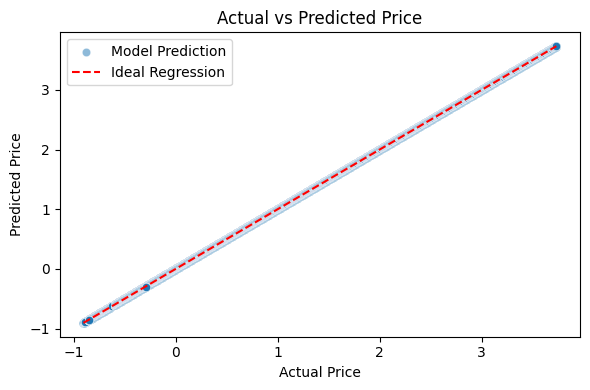

In [14]:
plot_prediction(y, y_result)

### 최소제곱법을 이용한 풀이

역행렬이 존재하지 않을 때 의사역행렬을 활용해 정답에 가까운 $\theta$를 구하는 방법

mse for lstsq: 7.237089724189386e-31


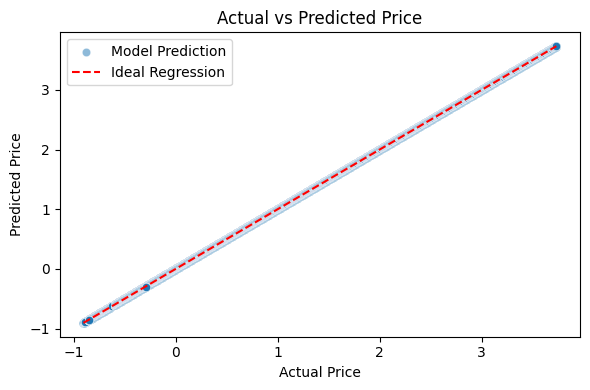

In [15]:
# np.linalg.lstsq로 최소제곱법으로 theta를 구할 수 있음
theta_lstsq, _, _, _ = np.linalg.lstsq(xmat_wbeta, y, rcond=None)
y_result = xmat_wbeta @ theta_lstsq
mse = np.mean((y_result - y) ** 2)
print(f'mse for lstsq: {mse}')
plot_prediction(y, y_result)

## 경사하강법

데이터의 양이 늘어나게 될 경우 수학적 풀이는 필요한 연산 횟수가 비현실적으로 많아진다.

경사하강법은 실험과 평가를 통해 최적의 $\theta$를 찾아내는 방법

1. 적당한 첫 $\theta$를 정한다.
2. $\theta$ 지점에서의 비용함수의 경사(미분값)을 구한다.
3. 경사도를 바탕으로 $\theta$를 조정한다.
4. 이를 정해진 횟수만큼, 또는 다른 기준을 만족할 때 까지 반복한다.

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:01<00:00, 3261.79it/s]

[np.float64(0.06536418743515442), np.float64(0.06491373154124937), np.float64(0.06446667078261906), np.float64(0.06402297329091086), np.float64(0.0635826076721145), np.float64(0.06314554299487464), np.float64(0.06271174877922497), np.float64(0.062281194985718887), np.float64(0.06185385200493552), np.float64(0.06142969064734089)]
최종 θ: [ 1.08766738e-17  1.81101788e-02 -1.27076281e-03 -3.14808562e-04
  9.95197251e-01 -1.77644533e-02  2.08784125e-03  2.23613355e-03]
최종 MSE: 1.0541810394037816e-05


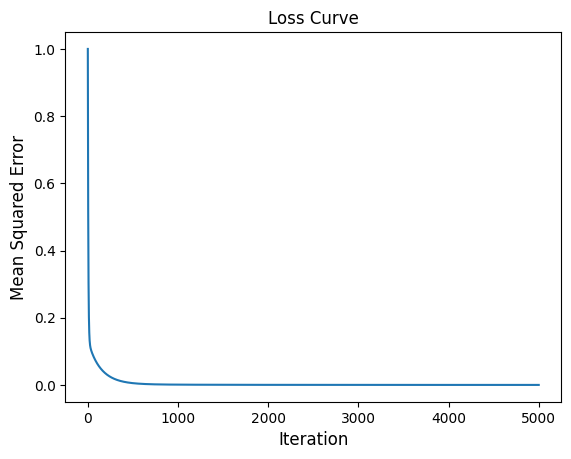

In [16]:
# 초기 theta
_, n = xmat_norm.shape 
theta = np.zeros(n+1)
# 학습률
alpha = 0.01
# 반복 횟수
iterations = 5000
# 비용 계산 결과 기록
loss_history = []

# 정해진 iterations 수만큼
for i in tqdm(range(iterations)):
    # 예측값 계산
    y_pred = (xmat_wbeta @ theta).flatten()

    # 오차를 바탕으로 MSE 계산 및 기록
    error = y_pred - y
    mse = np.mean(error**2)
    loss_history.append(mse)

    # 식을 토대로 경사(gradient) 계산
    gradient = (2/m) * xmat_wbeta.T @ error

    # 학습률을 가지고 theta 업데이트
    theta -= alpha * gradient

print(loss_history[100:110])
print("최종 θ:", theta.flatten())
print("최종 MSE:", loss_history[-1])

import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.xlabel("Iteration", size="large")
plt.ylabel("Mean Squared Error", size="large")
plt.title("Loss Curve", size="large")
plt.show()